In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

In [2]:
movies = pd.read_csv('movie.csv')  
ratings = pd.read_csv('rating.csv')  
tags = pd.read_csv('tag.csv')  

In [3]:
print("Filmler veri seti:")
print(movies.head())

print("\nPuanlar veri seti:")
print(ratings.head())   

print("\nEtiketler veri seti:")
print(tags.head())

Filmler veri seti:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Puanlar veri seti:
   userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40

Etiketler veri seti:
   userId  movieId            tag            timestamp
0

In [4]:
print("Veri Seti Boyutları:")
print(f"Filmler: {movies.shape[0]:,} satır, {movies.shape[1]} sütun")
print(f"Puanlar: {ratings.shape[0]:,} satır, {ratings.shape[1]} sütun")
print(f"Etiketler: {tags.shape[0]:,} satır, {tags.shape[1]} sütun")

Veri Seti Boyutları:
Filmler: 27,278 satır, 3 sütun
Puanlar: 20,000,263 satır, 4 sütun
Etiketler: 465,564 satır, 4 sütun


In [5]:
print(f"Toplam film sayısı: {movies['movieId'].nunique()}")
print(f"Toplam kullanıcı sayısı: {ratings['userId'].nunique()}")
print(f"Toplam Puan sayısı: {len(ratings)}")
print(f"Ortalama Puan: {ratings['rating'].mean():.2f}")

Toplam film sayısı: 27278
Toplam kullanıcı sayısı: 138493
Toplam Puan sayısı: 20000263
Ortalama Puan: 3.53


In [6]:
most_rated = ratings.groupby("movieId").size().reset_index(name="Rating_Count")
most_rated = most_rated.sort_values("Rating_Count", ascending=False)

most_rated = most_rated.merge(movies, on="movieId")

print("En Çok Puanlanan Filmler:")
print(most_rated[['title', 'Rating_Count']].head(10))


En Çok Puanlanan Filmler:
                                       title  Rating_Count
0                        Pulp Fiction (1994)         67310
1                        Forrest Gump (1994)         66172
2           Shawshank Redemption, The (1994)         63366
3           Silence of the Lambs, The (1991)         63299
4                       Jurassic Park (1993)         59715
5  Star Wars: Episode IV - A New Hope (1977)         54502
6                          Braveheart (1995)         53769
7          Terminator 2: Judgment Day (1991)         52244
8                         Matrix, The (1999)         51334
9                    Schindler's List (1993)         50054


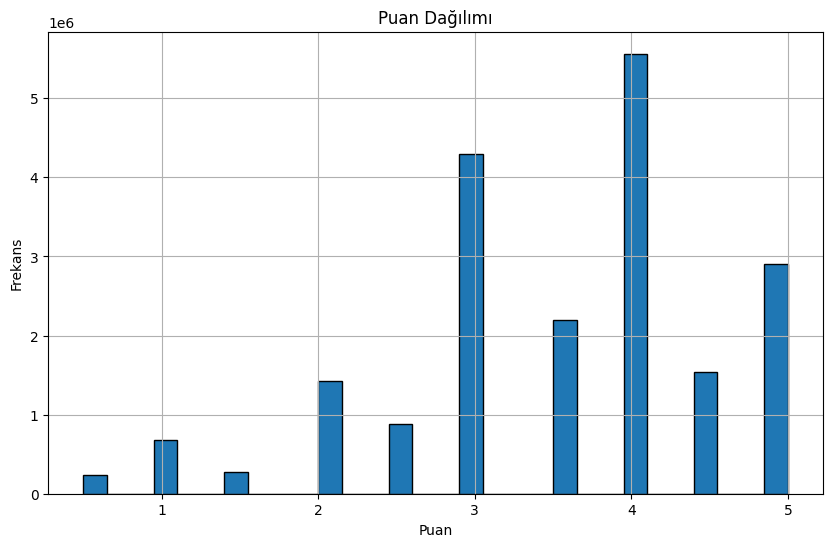

In [7]:
plt.figure(figsize=(10,6))
ratings['rating'].hist(bins=30, edgecolor='black')
plt.title('Puan Dağılımı')
plt.xlabel('Puan')
plt.ylabel('Frekans')
plt.show()

Kullanıcı Başına Puan Sayısı İstatistikleri:
Ortalama: 144.41
Median: 68.0
Maksimum: 9254
Minimum: 20


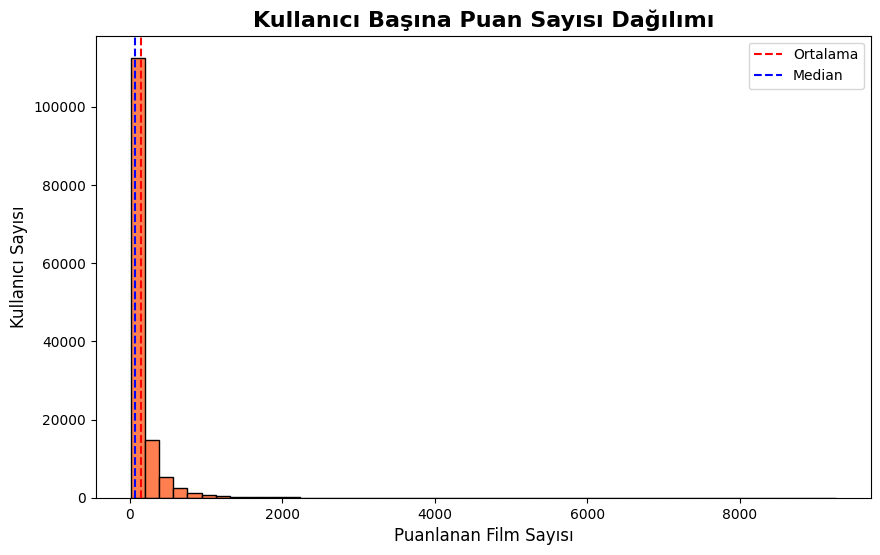

In [8]:
user_activity = ratings.groupby('userId').size().reset_index(name='num_ratings')
print("Kullanıcı Başına Puan Sayısı İstatistikleri:")
print(f"Ortalama: {user_activity['num_ratings'].mean():.2f}")
print(f"Median: {user_activity['num_ratings'].median()}")
print(f"Maksimum: {user_activity['num_ratings'].max()}")
print(f"Minimum: {user_activity['num_ratings'].min()}")


plt.figure(figsize=(10, 6))
plt.hist(user_activity['num_ratings'], bins=50, color='coral', edgecolor='black')
plt.title('Kullanıcı Başına Puan Sayısı Dağılımı', fontsize=16, fontweight='bold')
plt.xlabel('Puanlanan Film Sayısı', fontsize=12)
plt.ylabel('Kullanıcı Sayısı', fontsize=12)
plt.axvline(user_activity['num_ratings'].mean(), color='red', linestyle='--', label='Ortalama')
plt.axvline(user_activity['num_ratings'].median(), color='blue', linestyle='--', label='Median')
plt.legend()
plt.show()

In [9]:
all_genres=[]
for genres in movies["genres"].dropna():
    all_genres.extend(genres.split("|"))
    
from collections import Counter
genre_counts = Counter(all_genres)

print("En Popüler Türler:")
for genre, count in genre_counts.most_common(10):
    print(f"{genre}: {count} film")

En Popüler Türler:
Drama: 13344 film
Comedy: 8374 film
Thriller: 4178 film
Romance: 4127 film
Action: 3520 film
Crime: 2939 film
Horror: 2611 film
Documentary: 2471 film
Adventure: 2329 film
Sci-Fi: 1743 film


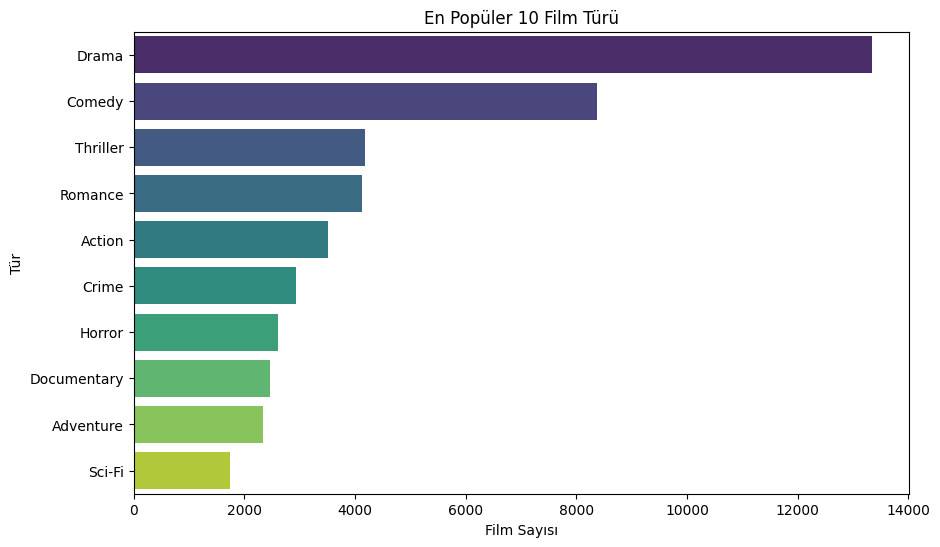

In [10]:
plt.figure(figsize=(10,6))
genres_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count'])
genres_df = genres_df.sort_values(by='Count', ascending=False)
sns.barplot(data=genres_df.head(10), x='Count', y='Genre', palette='viridis')
plt.title('En Popüler 10 Film Türü')
plt.xlabel('Film Sayısı')
plt.ylabel('Tür')
plt.show()


In [11]:
num_users= ratings['userId'].nunique()
num_movies= ratings['movieId'].nunique()
print(f"Toplam Kullanıcı Sayısı: {num_users}")
print(f"Toplam Film Sayısı: {num_movies}")

max_possible_ratings= num_users * num_movies
print(f"Maksimum Olası Puan Sayısı: {max_possible_ratings}")
actual_ratings= len(ratings)
print(f"Gerçek Puan Sayısı: {actual_ratings}")
sparsity=(actual_ratings / max_possible_ratings)*100
print(f"Doluluk Oranı: {sparsity:.6f}%")
print(f"Puan Matrisi Seyrekliği: {100 - sparsity:.6f}%")

Toplam Kullanıcı Sayısı: 138493
Toplam Film Sayısı: 26744
Maksimum Olası Puan Sayısı: 3703856792
Gerçek Puan Sayısı: 20000263
Doluluk Oranı: 0.539985%
Puan Matrisi Seyrekliği: 99.460015%


In [12]:
print("Filmlerdeki Eksik Değerler:")
print(movies.isnull().sum())

print("Puanlardaki Eksik Değerler:")
print(ratings.isnull().sum())

print("Etiketlerdeki Eksik Değerler:")
print(tags.isnull().sum())


Filmlerdeki Eksik Değerler:
movieId    0
title      0
genres     0
dtype: int64
Puanlardaki Eksik Değerler:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Etiketlerdeki Eksik Değerler:
userId        0
movieId       0
tag          16
timestamp     0
dtype: int64


In [13]:
print("Duplicate Kontrolleri:")
print("Filmlerdeki Yinelemeler:")
print(movies.duplicated().sum())
print("Puanlardaki Yinelemeler:")
print(ratings.duplicated().sum())
print("Etiketlerdeki Yinelemeler:")
print(tags.duplicated().sum())

Duplicate Kontrolleri:
Filmlerdeki Yinelemeler:
0
Puanlardaki Yinelemeler:
0
Etiketlerdeki Yinelemeler:
0


Outlier Analizi:


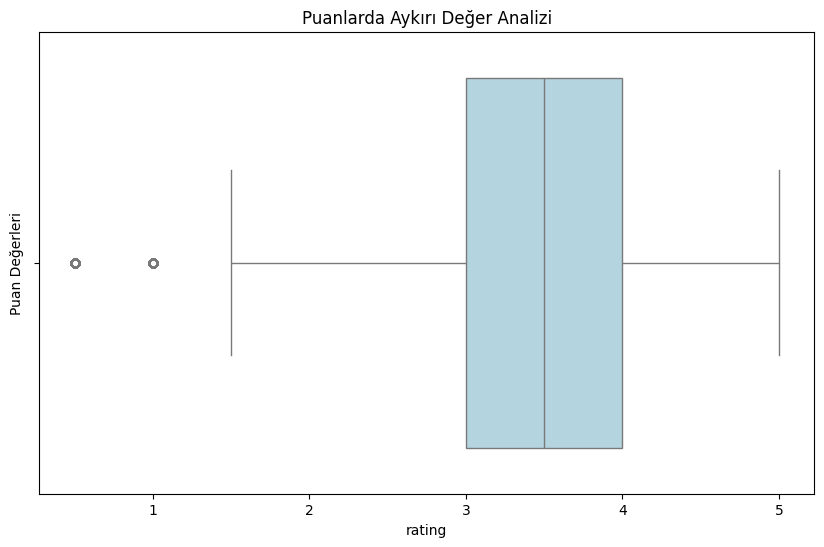

In [14]:
print("Outlier Analizi:")
plt.figure(figsize=(10,6))
sns.boxplot(x=ratings['rating'], color='lightblue')
plt.title('Puanlarda Aykırı Değer Analizi')
plt.ylabel('Puan Değerleri')
plt.show()

In [15]:
top_users = ratings.groupby('userId').size().nlargest(1000).index
top_movies = ratings.groupby('movieId').size().nlargest(500).index

filtered_data = ratings[ratings['userId'].isin(top_users) & ratings['movieId'].isin(top_movies)]

print(f"Kullanıcı sayısı (filtrelenmiş): {filtered_data['userId'].nunique()}")
print(f"Film sayısı (filtrelenmiş): {filtered_data['movieId'].nunique()}")
print(f"Puan sayısı (filtrelenmiş): {len(filtered_data)}")

Kullanıcı sayısı (filtrelenmiş): 1000
Film sayısı (filtrelenmiş): 500
Puan sayısı (filtrelenmiş): 364524


In [16]:
matrix= filtered_data.pivot(index='userId', columns='movieId', values='rating')
print("Puan Matrisi (Kullanıcı- Film):")
print(matrix.head())

Puan Matrisi (Kullanıcı- Film):
movieId  1      2      3      5      6      7      10     11     16     17     \
userId                                                                          
156        5.0    5.0    2.0    3.0    4.0    4.0    4.0    5.0    4.0    4.0   
208        4.0    NaN    NaN    NaN    NaN    NaN    NaN    3.0    1.5    5.0   
359        5.0    NaN    NaN    NaN    5.0    NaN    4.0    4.0    NaN    NaN   
572        5.0    3.5    3.5    3.5    NaN    NaN    NaN    3.5    4.0    NaN   
586        2.5    3.0    2.0    3.0    4.5    NaN    4.0    2.5    4.5    NaN   

movieId  ...  54286  55820  56367  58559  59315  60069  68157  68954  72998  \
userId   ...                                                                  
156      ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
208      ...    4.5    4.0    4.5    3.5    NaN    3.5    4.0    4.5    2.5   
359      ...    4.5    4.0    NaN    4.0    3.5    NaN    4.0    NaN    4.5   
572  

In [17]:
matrix_filled= matrix.fillna(0)

similarity= cosine_similarity(matrix_filled)
similarity_df= pd.DataFrame(similarity, index=matrix.index, columns=matrix.index)

print(f"Benzerlik Matrisi Boyutu: {similarity_df.shape}")
print(similarity_df.iloc[:5, :5])

Benzerlik Matrisi Boyutu: (1000, 1000)
userId       156       208       359       572       586
userId                                                  
156     1.000000  0.639232  0.668767  0.605267  0.712618
208     0.639232  1.000000  0.651821  0.570471  0.698602
359     0.668767  0.651821  1.000000  0.618573  0.740590
572     0.605267  0.570471  0.618573  1.000000  0.700544
586     0.712618  0.698602  0.740590  0.700544  1.000000


In [18]:
def recommend (user_id, num_recommendations=5):
    if user_id not in similarity_df.index:
        print("Kullanıcı bulunamadı.")
        return []
    
    user_similarities = similarity_df.loc[user_id]
    similar_users = user_similarities.sort_values(ascending=False).index[1:]
    
    user_ratings = matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings.isnull()].index
    
    movie_scores = {}
    
    for similar_user in similar_users:
        similar_user_ratings = matrix.loc[similar_user]
        for movie in unrated_movies:
            if not np.isnan(similar_user_ratings[movie]):
                if movie not in movie_scores:
                    movie_scores[movie] = 0
                movie_scores[movie] += similar_user_ratings[movie] * user_similarities[similar_user]
    
    sorted_movies = sorted(movie_scores.items(), key=lambda x: x[1], reverse=True)
    recommended_movies = [movie for movie, score in sorted_movies[:num_recommendations]]
    
    recommended_titles = movies[movies['movieId'].isin(recommended_movies)]['title'].tolist()
    
    return recommended_titles

test_user = matrix.index[0]
recs = recommend(test_user)

print(f"\n User {test_user} için öneriler:")
for i, rec in enumerate(recs, 1):
    print(f"{i}. {rec}")


 User 156 için öneriler:
1. Star Wars: Episode IV - A New Hope (1977)
2. 2001: A Space Odyssey (1968)
3. Goodfellas (1990)
4. Psycho (1960)
5. Lord of the Rings: The Return of the King, The (2003)


In [19]:
print(f" USER {test_user} ANALİZİ")

user_ratings = matrix.loc[test_user].dropna().sort_values(ascending=False)

print(f"\n User {test_user}:")
print(f"   Toplam izlediği film: {len(user_ratings)}")
print(f"   Ortalama puan: {user_ratings.mean():.2f}")

print(f"\n EN YÜKSEK PUAN VERDİĞİ 10 FİLM:")
for i, (movie_id, rating) in enumerate(user_ratings.head(10).items(), 1):
    movie_title = movies[movies['movieId'] == movie_id]['title'].iloc[0]
    genres = movies[movies['movieId'] == movie_id]['genres'].iloc[0]
    print(f"{i}. {movie_title}: {rating}")
    print(f"   Türler: {genres}")

print(f"\n TÜR TERCİHLERİ:")
all_genres = []
for movie_id in user_ratings.index:
    genre_str = movies[movies['movieId'] == movie_id]['genres'].iloc[0]
    all_genres.extend(genre_str.split('|'))

from collections import Counter
genre_counts = Counter(all_genres)

for genre, count in genre_counts.most_common(5):
    print(f"   {genre}: {count} film (%{(count/len(user_ratings))*100:.1f})")

print(f"\n ÖNERİLEN FİLMLER:")
recs = recommend(test_user, num_recommendations=5)
for i, title in enumerate(recs, 1):
    print(f"{i}. {title}")

 USER 156 ANALİZİ

 User 156:
   Toplam izlediği film: 352
   Ortalama puan: 4.14

 EN YÜKSEK PUAN VERDİĞİ 10 FİLM:
1. Toy Story (1995): 5.0
   Türler: Adventure|Animation|Children|Comedy|Fantasy
2. Jumanji (1995): 5.0
   Türler: Adventure|Children|Fantasy
3. Shrek (2001): 5.0
   Türler: Adventure|Animation|Children|Comedy|Fantasy|Romance
4. M*A*S*H (a.k.a. MASH) (1970): 5.0
   Türler: Comedy|Drama|War
5. Star Wars: Episode II - Attack of the Clones (2002): 5.0
   Türler: Action|Adventure|Sci-Fi|IMAX
6. Lord of the Rings: The Two Towers, The (2002): 5.0
   Türler: Adventure|Fantasy
7. Italian Job, The (2003): 5.0
   Türler: Action|Crime
8. Mask of Zorro, The (1998): 5.0
   Türler: Action|Comedy|Romance
9. Saving Private Ryan (1998): 5.0
   Türler: Action|Drama|War
10. Lady and the Tramp (1955): 5.0
   Türler: Animation|Children|Comedy|Romance

 TÜR TERCİHLERİ:
   Drama: 140 film (%39.8)
   Comedy: 137 film (%38.9)
   Action: 119 film (%33.8)
   Thriller: 104 film (%29.5)
   Adventure: 

In [20]:
#Content-Based Filtering Yöntemi
print("Content-Based Filtering Yöntemi")
movies_clean=movies.copy()
movies_clean['genres'] = movies_clean['genres'].fillna('')
movies_clean = movies_clean[movies_clean['genres'] != '']
movies_clean['genres'] = movies_clean['genres'].str.replace('|', ' ')

print(f"Film sayısı: {len(movies_clean)}")

Content-Based Filtering Yöntemi
Film sayısı: 27278


In [21]:
tfidf=TfidfVectorizer(stop_words='english')
tfidf_matrix=tfidf.fit_transform(movies_clean['genres'])
print(f"TF-İDF Matrisi Boyutu: {tfidf_matrix.shape}")

TF-İDF Matrisi Boyutu: (27278, 23)


In [22]:
print(f"Benzerlik")
cosine_sim= cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Benzerlik Matrisi Boyutu: {cosine_sim.shape}")

Benzerlik
Benzerlik Matrisi Boyutu: (27278, 27278)


In [23]:
def content_based_recommendations(movie_title, num_recommendations=10):
    if movie_title not in movies_clean['title'].values:
        print("Film bulunamadı.")
        return []
    
    movie_idx = movies_clean[movies_clean['title'] == movie_title].index[0]
    sim_scores = list(enumerate(cosine_sim[movie_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:num_recommendations+1]
    
    movie_indices = [i[0] for i in sim_scores]
    results=[]
    for i , idx in enumerate(movie_indices, 1):
        title=movies_clean['title'].iloc[idx]
        genres=movies_clean['genres'].iloc[idx]
        similarity_score=sim_scores[i-1][1]
        results.append({
            "index": i,
            "title": title,
            "genres": genres,
            "similarity": similarity_score
        })
    return results

print(f"\n Content-Based Öneriler için Örnek Film: Toy Story (1995)")
test_movie = "Toy Story (1995)"
recommendations = content_based_recommendations(test_movie, num_recommendations=10)
for rec in recommendations:
    print(f"{rec['index']}. {rec['title']} - Türler: {rec['genres']} (Benzerlik: {rec['similarity']:.4f})")


 Content-Based Öneriler için Örnek Film: Toy Story (1995)
1. Antz (1998) - Türler: Adventure Animation Children Comedy Fantasy (Benzerlik: 1.0000)
2. Toy Story 2 (1999) - Türler: Adventure Animation Children Comedy Fantasy (Benzerlik: 1.0000)
3. Adventures of Rocky and Bullwinkle, The (2000) - Türler: Adventure Animation Children Comedy Fantasy (Benzerlik: 1.0000)
4. Emperor's New Groove, The (2000) - Türler: Adventure Animation Children Comedy Fantasy (Benzerlik: 1.0000)
5. Monsters, Inc. (2001) - Türler: Adventure Animation Children Comedy Fantasy (Benzerlik: 1.0000)
6. DuckTales: The Movie - Treasure of the Lost Lamp (1990) - Türler: Adventure Animation Children Comedy Fantasy (Benzerlik: 1.0000)
7. Wild, The (2006) - Türler: Adventure Animation Children Comedy Fantasy (Benzerlik: 1.0000)
8. Shrek the Third (2007) - Türler: Adventure Animation Children Comedy Fantasy (Benzerlik: 1.0000)
9. Tale of Despereaux, The (2008) - Türler: Adventure Animation Children Comedy Fantasy (Benzerl

In [24]:
test_movie = "Matrix, The (1999)"
movie_info=movies_clean[movies_clean['title']==test_movie].iloc[0]
print(f"Content-Based Öneriler için Örnek Film: {test_movie}")
print(f"Türler: {movie_info['genres']}")
recommendations = content_based_recommendations(test_movie, num_recommendations=10)
for rec in recommendations:
    print(f"{rec['index']}. {rec['title']} - Türler: {rec['genres']} (Benzerlik: {rec['similarity']:.4f})")

Content-Based Öneriler için Örnek Film: Matrix, The (1999)
Türler: Action Sci-Fi Thriller
1. Screamers (1995) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
2. Johnny Mnemonic (1995) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
3. Nemesis 2: Nebula (1995) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
4. Virtuosity (1995) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
5. Timecop (1994) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
6. Blade Runner (1982) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
7. Solo (1996) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
8. Arrival, The (1996) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
9. Terminator, The (1984) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)
10. Godzilla (1998) - Türler: Action Sci-Fi Thriller (Benzerlik: 1.0000)


In [25]:
def improved_recommend(movie_title, num=10):
    idx = movies_clean[movies_clean['title'] == movie_title].index[0]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:51]
    
    results = []
    for i, sim in sim_scores:
        movie_id = movies_clean.iloc[i]['movieId']
        title = movies_clean.iloc[i]['title']
        
        avg_rating = ratings[ratings['movieId'] == movie_id]['rating'].mean()
        
        score = sim * avg_rating
        
        results.append({'title': title, 'score': score, 'rating': avg_rating})
    
    results = sorted(results, key=lambda x: x['score'], reverse=True)[:num]
    return results

recs = improved_recommend("Matrix, The (1999)")

print("\n Matrix için iyileştirilmiş öneriler:\n")
for i, rec in enumerate(recs, 1):
    print(f"{i}. {rec['title']} (Rating: {rec['rating']:.2f})")


 Matrix için iyileştirilmiş öneriler:

1. Matrix, The (1999) (Rating: 4.19)
2. Blade Runner (1982) (Rating: 4.13)
3. Terminator, The (1984) (Rating: 3.90)
4. Equilibrium (2002) (Rating: 3.77)
5. Predator (1987) (Rating: 3.62)
6. Cypher (2002) (Rating: 3.60)
7. Chronicle (2012) (Rating: 3.59)
8. Déjà Vu (Deja Vu) (2006) (Rating: 3.59)
9. They Live (1988) (Rating: 3.57)
10. Island, The (2005) (Rating: 3.40)


In [26]:
def hybrid_recommend(user_id, num=10):
    if user_id not in matrix.index:
        print("Kullanıcı yok!")
        return []
    
    user_ratings = matrix.loc[user_id].dropna()
    favorites = user_ratings[user_ratings >= 4.0]
    
    if len(favorites) == 0:
        return []
    
    all_scores = {}
    
    for movie_id in favorites.index:
        if movie_id not in movies_clean['movieId'].values:
            continue
            
        idx = movies_clean[movies_clean['movieId'] == movie_id].index[0]
        
        for i, score in enumerate(cosine_sim[idx]):
            rec_movie_id = movies_clean.iloc[i]['movieId']
            
            if rec_movie_id not in user_ratings.index:
                if rec_movie_id not in all_scores:
                    all_scores[rec_movie_id] = 0
                all_scores[rec_movie_id] += score
    
    sorted_movies = sorted(all_scores.items(), key=lambda x: x[1], reverse=True)[:num]
    
    results = []
    for movie_id, score in sorted_movies:
        title = movies[movies['movieId'] == movie_id]['title'].values[0]
        results.append(title)
    
    return results

In [27]:
print("User 156 için:")

print("\n1. COLLABORATIVE:")
collab = recommend(156, 5)
for i, t in enumerate(collab, 1):
    print(f"   {i}. {t}")

print("\n2. HYBRID:")
hybrid = hybrid_recommend(156, 5)
for i, t in enumerate(hybrid, 1):
    print(f"   {i}. {t}")

User 156 için:

1. COLLABORATIVE:
   1. Star Wars: Episode IV - A New Hope (1977)
   2. 2001: A Space Odyssey (1968)
   3. Goodfellas (1990)
   4. Psycho (1960)
   5. Lord of the Rings: The Return of the King, The (2003)

2. HYBRID:
   1. Stunt Man, The (1980)
   2. The 39 Steps (1959)
   3. Getaway, The (1994)
   4. Kaho Naa... Pyaar Hai (2000)
   5. Chase, The (1994)


In [28]:
def ultimate_recommend(user_id, num=10):
    collab = recommend(user_id, num) 
    hybrid = hybrid_recommend(user_id, num)
    
    results = []
    seen_movies = set() 
    
    max_len = max(len(collab), len(hybrid))
    
    for i in range(max_len):
        if i < len(collab):
            movie = collab[i]
            if movie not in seen_movies:
                results.append(("COLLABORATIVE", movie))
                seen_movies.add(movie)
        
        if i < len(hybrid):
            movie = hybrid[i]
            if movie not in seen_movies:
                results.append(("HYBRID", movie))
                seen_movies.add(movie)
        
        if len(results) >= num:
            break
            
    return results

print(" ULTIMATE RECOMMENDATION")

final_recs = ultimate_recommend(156, 10)

print(f"\n User 156 için FINAL öneriler:\n")
for i, (method, title) in enumerate(final_recs, 1):
    print(f"{i}. {title}")
    print(f"   Yöntem: {method}\n")


 ULTIMATE RECOMMENDATION

 User 156 için FINAL öneriler:

1. Star Wars: Episode IV - A New Hope (1977)
   Yöntem: COLLABORATIVE

2. Stunt Man, The (1980)
   Yöntem: HYBRID

3. 2001: A Space Odyssey (1968)
   Yöntem: COLLABORATIVE

4. The 39 Steps (1959)
   Yöntem: HYBRID

5. Princess Bride, The (1987)
   Yöntem: COLLABORATIVE

6. Getaway, The (1994)
   Yöntem: HYBRID

7. Goodfellas (1990)
   Yöntem: COLLABORATIVE

8. Kaho Naa... Pyaar Hai (2000)
   Yöntem: HYBRID

9. Psycho (1960)
   Yöntem: COLLABORATIVE

10. Chase, The (1994)
   Yöntem: HYBRID

